# Wikipedia Edit Wars — Sentez Raporu (Faz 8)

Bu notebook, projenin 7 fazında (veri toplama, temizlik, zaman serisi,
network analizi, NLP, iki tahmin modeli) üretilen tabloları okuyup temel
bulguları tek yerde toplar. Her sonucun nasıl üretildiğinin detayı ilgili
`src/phaseN_*` klasöründe ve `git log` geçmişinde.

In [1]:
import sqlite3
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from config.settings import DB_PATH

pd.set_option("display.max_colwidth", 60)
conn = sqlite3.connect(DB_PATH)
print(f"DB: {DB_PATH}")

DB: /Users/ilsuyuksel/PycharmProjects/wikipedia-edit-wars/data/raw/wikipedia_edit_wars.db


## 1. Veri Toplama Özeti (Faz 1)

In [2]:
pages = pd.read_sql_query("SELECT * FROM pages", conn)
revisions = pd.read_sql_query("SELECT COUNT(*) AS n FROM revisions", conn)

print(f"Toplam sayfa: {len(pages)} ({(pages.label=='controversial').sum()} tartışmalı, "
      f"{(pages.label=='control').sum()} kontrol)")
print(f"Toplam revizyon: {revisions['n'].iloc[0]:,}")

Toplam sayfa: 40 (20 tartışmalı, 20 kontrol)
Toplam revizyon: 78,639


## 2. En Çatışmalı Sayfalar (Faz 4)

Ham `revert_rate` yerine, Faz 4'te doğrulanan **`core_conflict_ratio`**
kullanılıyor — sayfadaki editörlerin ne kadarının gerçek, karşılıklı
revert ilişkisi içinde (tek seferlik vandalizm değil) olduğunu gösterir.

,page_title,page_label,core_conflict_ratio,num_editors_in_core_conflict,num_editors_in_graph
34,Taiwan,controversial,0.228916,38,166
0,Abortion,controversial,0.221557,37,167
39,Zionism,controversial,0.196078,20,102
21,Israeli–Palestinian conflict,controversial,0.186667,14,75
31,Russo-Ukrainian war (2022–present),controversial,0.156250,10,64


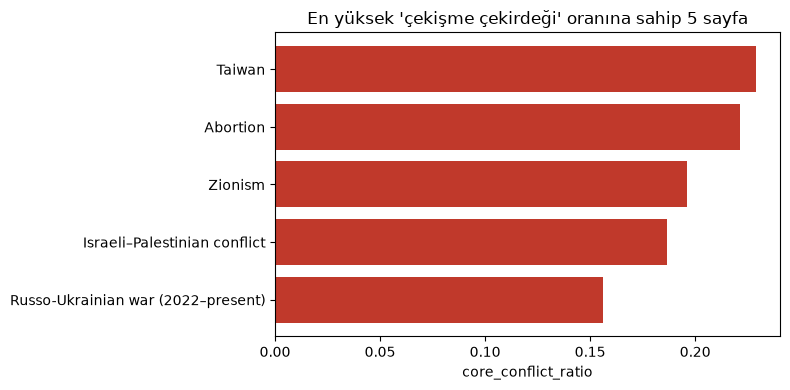

In [3]:
page_net = pd.read_sql_query("SELECT * FROM page_network_features", conn)

top5 = page_net.sort_values("core_conflict_ratio", ascending=False).head(5)
display(top5[["page_title", "page_label", "core_conflict_ratio",
              "num_editors_in_core_conflict", "num_editors_in_graph"]])

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c0392b" if l == "controversial" else "#7f8c8d" for l in top5["page_label"]]
ax.barh(top5["page_title"][::-1], top5["core_conflict_ratio"][::-1], color=colors[::-1])
ax.set_xlabel("core_conflict_ratio")
ax.set_title("En yüksek 'çekişme çekirdeği' oranına sahip 5 sayfa")
plt.tight_layout()
plt.show()

## 3. Tipik Bir Edit War'ın Anatomisi: Vandalizm vs Gerçek Çekişme (Faz 2)

Ham revert oranı kontrol ve tartışmalı sayfaları ayırt etmiyor — ikisi de
yüksek olabiliyor ama NEDENİ farklı. Kontrol sayfalarındaki revertler
büyük ölçüde anonim/tek-seferlik (vandalizm temizliği); tartışmalı
sayfalardakiler az sayıda kayıtlı editör arasında tekrarlanıyor.

In [4]:
page_scores = pd.read_sql_query("SELECT * FROM page_conflict_scores", conn)

comparison = page_scores.groupby("page_label")[
    ["revert_rate", "anon_reverted_ratio", "reciprocal_revert_pairs", "revert_concentration_hhi"]
].mean()
comparison.columns = ["ham revert oranı", "geri alınanların anonim oranı",
                       "karşılıklı revert çifti (ort.)", "revert yoğunlaşma (HHI)"]
display(comparison.round(3))

,ham revert oranı,geri alınanların anonim oranı,karşılıklı revert çifti (ort.),revert yoğunlaşma (HHI)
page_label,,,,
control,0.191,0.506,6.1,0.044
controversial,0.108,0.117,9.2,0.080


## 4. Görsel Özet: Network, Zaman Serisi

Örnek sayfalar (tam galeri `reports/figures/` altında).

| Abortion (tartışmalı) — network | Igneous rock (kontrol) — network |
|---|---|
| ![](../reports/figures/network_abortion.png) | ![](../reports/figures/network_igneous_rock.png) |

| Abortion — zaman çizgisi |
|---|
| ![](../reports/figures/timeline_abortion.png) |

## 5. Model 1 — Revert Prediction (Revizyon Seviyesi, Faz 6)

,model,roc_auc,recall_class1
0,Logistic Regression,0.827,0.70
1,Random Forest,0.888,0.77
2,XGBoost,0.893,0.78


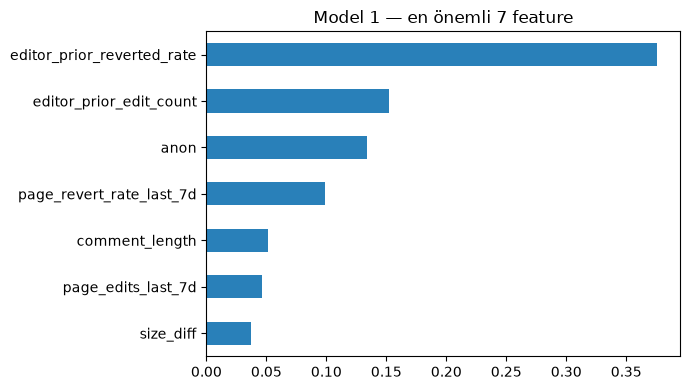

In [5]:
model1_results = pd.DataFrame([
    {"model": "Logistic Regression", "roc_auc": 0.827, "recall_class1": 0.70},
    {"model": "Random Forest",       "roc_auc": 0.888, "recall_class1": 0.77},
    {"model": "XGBoost",             "roc_auc": 0.893, "recall_class1": 0.78},
])
display(model1_results)

feature_importance_m1 = pd.Series({
    "editor_prior_reverted_rate": 0.376, "editor_prior_edit_count": 0.152,
    "anon": 0.134, "page_revert_rate_last_7d": 0.099, "comment_length": 0.051,
    "page_edits_last_7d": 0.046, "size_diff": 0.037,
}).sort_values()
feature_importance_m1.plot(kind="barh", figsize=(7, 4), color="#2980b9", title="Model 1 — en önemli 7 feature")
plt.tight_layout()
plt.show()

En güçlü sinyal `editor_prior_reverted_rate` — editörün geçmişte ne sıklıkla geri alındığı ('itibar' etkisi). Detaylı SHAP grafiği: `reports/figures/shap_summary_model1.png`.

## 6. Model 2 — Edit War Öngörüsü (Sayfa-Hafta Seviyesi, Faz 7)

Hedef: önümüzdeki 4 hafta içinde sayfada karşılıklı-revert tipi bir
çekişme olacak mı. Kronolojik split (son %20 zaman dilimi test).

In [6]:
model2_results = pd.DataFrame([
    {"model": "Logistic Regression", "roc_auc": 0.755, "recall_class1": 0.87, "precision_class1": 0.08},
    {"model": "Random Forest",       "roc_auc": 0.681, "recall_class1": 0.60, "precision_class1": 0.09},
    {"model": "XGBoost",             "roc_auc": 0.578, "recall_class1": 0.39, "precision_class1": 0.07},
])
display(model2_results)

,model,roc_auc,recall_class1,precision_class1
0,Logistic Regression,0.755,0.87,0.08
1,Random Forest,0.681,0.60,0.09
2,XGBoost,0.578,0.39,0.07


**Not:** Precision düşük (~%8) — bu bir hata değil, veri setinin
küçüklüğünün (40 sayfa) doğal sonucu: gerçek "çekişme dönemi" olayları
seyrek. Bir erken-uyarı sistemi için yüksek recall (LR: %87) düşük
precision'a tercih edilebilir — editörlere "izlenecek sayfalar" listesi
sunmak, yanlış alarmları tolere edebilir bir kullanım senaryosu.

## 7. Sonuç ve Öneriler

- Ham metrikler (`revert_rate`, `num_communities`) tek başına yanıltıcı —
  network yapısı (karşılıklılık, çekişme çekirdeği) asıl ayırt edici sinyal.
- Editör geçmişi tek bir revizyonun geri alınma riskini güçlü tahmin ediyor
  (ROC-AUC 0.89) — bu pratikte bir "gerçek zamanlı review önceliklendirme"
  aracına dönüştürülebilir.
- Sayfa-seviyeli edit-war öngörüsü daha zor — daha fazla sayfa/daha uzun
  geçmiş, veya Talk sayfası verisiyle zenginleştirme gelecek çalışma için
  doğal bir sonraki adım.
- Edit summary metinleri (NLP) beklenenden zayıf sinyal verdi — gerçek
  tartışma muhtemelen Talk sayfalarında, bu projenin kapsamı dışında.